In [ ]:
import anndata as ad
import scanpy as sc
from sklearn.model_selection import train_test_split
import pylab as pl
import seaborn as sns
from limix_core.util.preprocess import gaussianize, regressOut
import scipy.stats as st
from histogwas import VCTEST
from pandas_plink import read_plink
from sklearn.impute import SimpleImputer
import scipy.linalg as la
from histogwas.emb_gwas.utils import df_match
import histogwas.emb_gwas as eg
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
from os.path import join

In [3]:
tissue = 'Thyroid'
pcfile='/lustre/groups/casale/datasets/gtex/wgs/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF01.pca.eigenvec'
bfile='/lustre/groups/casale/datasets/gtex/wgs/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF02'
outdir = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage8/Task5_Visualization/{tissue}'
# os.makedirs(outdir, exist_ok=True)

# # Reading the genotype
num_pcs = 4
gdata = eg.read_plink(bfile, pcfile, num_pcs=num_pcs)

Mapping files: 100%|██████████| 3/3 [00:12<00:00,  4.02s/it]


In [24]:
#Reading the anndata
hfile = f"/lustre/groups/casale/datasets/gtex/histology/20230425_v2_tiles/stage2/{tissue}/embedding/summary_scanpy.h5ad"
adata = ad.read_h5ad(hfile)

In [25]:
# read covs
def load_covs(covfile):
    dfcov0 = pd.read_csv(covfile, sep='\t').dropna()
    dfcov = pd.get_dummies(dfcov0['DTHHRDY'].astype(int).astype(str))
    dfcov['SEX'] = 1 * (dfcov0['SEX'].values==2)
    dfcov['AGE'] = dfcov0['AGE'].str.split('-').str.get(0).astype(int) + 5
    dfcov['SID'] = dfcov0['SUBJID']
    dfcov = dfcov.set_index('SID')
    return dfcov



def get_snp(snp, gdata):
    df_gene = pd.DataFrame(gdata.X[:,np.where(gdata.var.index == snp)[0]].compute())
    df_gene.index = gdata.obs.index
    return df_gene

def get_idata(adata, cluster_i):


    adata_new = adata[adata.obs['leiden_0.5']==cluster_i]

    # adata_new = adata


    idata = ad.AnnData(adata_new.obsm['X_pca'][:,:64], obs=adata_new.obs)
    _ = idata.obs['slide'].str.split('-')
    idata.obs['SID'] = _.str.get(0) + '-' + _.str.get(1)
    idata.obsm = adata_new.obsm
    
    _ = adata_new.obs['slide'].str.split('-')
    adata_new.obs['SID'] = _.str.get(0) + '-' + _.str.get(1)
    adata_new.obsm = adata_new.obsm
    adata_new = adata
    return idata, adata_new

In [26]:
covfile = '/lustre/groups/casale/datasets/gtex/phenotypes/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt'
dfcov = load_covs(covfile)

cluster_i = '2'
idata, adata_new = get_idata(adata, cluster_i)

# match idata, gdata and dfcov
idata, gdata, dfcov = eg.match_idata_gdata_dfcov(idata, gdata, dfcov, idata_bag_key='SID')
dfcov['AGE'] = (dfcov['AGE'] - dfcov['AGE'].mean(0)) / dfcov['AGE'].std(0)
dfpc = (gdata.obs - gdata.obs.mean(0)) / gdata.obs.std(0)
dfcovall = pd.concat([dfcov, dfpc], axis=1)


snp = 'chr9_97772921_C_G_b38'
snp_df = get_snp(snp, gdata)

<ipython-input-25-3ec6c9047240>:32: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_new.obs['SID'] = _.str.get(0) + '-' + _.str.get(1)
/lustre/groups/casale/code/users/shubham.chaudhary/projects/AIH-SGML/emb-gwas/emb_gwas/geno_utils.py:82: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  _X = self.X[idx1, idx2]


In [31]:
dfX = idata.to_df()
dfX['SID'] = idata.obs['SID'].values
dfX = dfX.groupby('SID').mean()

In [32]:
idxh, idxg, idxc = df_match([dfX, snp_df, dfcovall])
X = dfX.iloc[idxh].values
y = snp_df.iloc[idxg].values
y = SimpleImputer().fit_transform(y)
F = dfcovall.iloc[idxc].values

In [33]:
#regressing out the covariates from the embeddings
yr = regressOut(y, F)
Xr = regressOut(X, F)

In [34]:
# fit variant component model
vc = VCTEST()
res = vc.fit(X, yr)
ystar = vc.predict_loo()

100%|██████████| 100/100 [00:00<00:00, 1149.31it/s]


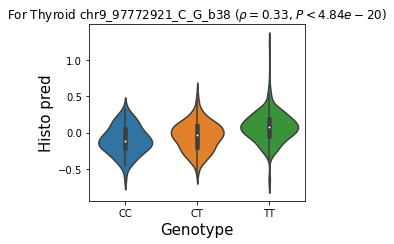

In [35]:
# visualize fit
outdir = '/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage8/Task9_plots/plot_4'
outfile = join(outdir, 'Thyroid_violin.PNG')
pl.figure(1, figsize=(4, 3.5))
plt = pl.subplot(1, 1, 1)
_rho, _pv = st.spearmanr(y.ravel(), ystar.ravel())
pl.title(f'For {tissue} {snp} ($\\rho={_rho:.2f}$, $P<{_pv:.2e}$)')
sns.violinplot(x=y.ravel(), y=ystar.ravel())
plt.set_xticks([0, 1, 2])
plt.set_xticklabels(['CC', 'CT', 'TT'])
pl.xlabel('Genotype', fontsize=15)
pl.ylabel('Histo pred', fontsize=15)
pl.tight_layout()
pl.savefig(outfile, dpi=300)

In [37]:
def get_adata_all(adata):
    # adata = adata[adata.obs['leiden_0.5'].isin(np.array(tissue_list['Thyroid']).astype(str))]
    idata = ad.AnnData(adata.obsm['X_pca'][:,:64], obs=adata.obs)
    _ = idata.obs['slide'].str.split('-')
    idata.obs['SID'] = _.str.get(0) + '-' + _.str.get(1)
    idata.obsm = adata.obsm
    
    return idata
idata_all = get_adata_all(adata)

In [38]:
# visualize on umap
idata.obs['ystar'] = vc.predict(idata.X).ravel()

# Also getting prediction for all idata
idata_all.obs['ystar'] = vc.predict(idata_all.X).ravel()

# Working on PGAN for interpolation

In [39]:
import sys

from torchvision.utils import make_grid
import json
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor, to_pil_image
import torch

os.chdir('/lustre/groups/casale/code/users/shubham.chaudhary/projects/AIH-SGML/pytorch_cGAN_zoo/pytorch_cGAN_zoo')
from models.progressive_gan import ProgressiveGAN as PGAN

In [40]:
class Generator():
    
    def __init__(self, config, checkpoint, useGPU=True):
        with open(config, 'rb') as file:
            config = json.load(file)
        self.pgan = PGAN(useGPU=useGPU, storeAVG=True, **config)
        self.pgan.load(checkpoint)
        self.netG = self.pgan.netG
        self.device = self.pgan.device
        
    def forward(self, x, eps=None):
        if eps is None:
            eps = torch.randn(x.shape[0], 512)
        if type(x)==np.ndarray:
            x = torch.Tensor(x)
        if type(eps)==np.ndarray:
            eps = torch.Tensor(eps)
        x = x.to(self.device)
        eps = eps.to(self.device)
        with torch.no_grad():
            out = self.netG(eps, x).data.cpu()
            out = 0.5 * (out + 1)
            out = torch.clip(out, 0, 1)
        return out
    
def load_image_torch(path, size):
    if type(path) in [list, np.ndarray]:
        return torch.cat([load_image_torch(_, size) for _ in path])
    return pil_to_tensor(Image.open(path).resize((size, size)))[None] / 255.


def torch_imshow(x):
    pl.imshow(x.permute(1, 2, 0))

In [41]:
config = '/lustre/groups/casale/code/users/paolo.casale/projects/pytorch_cGAN_zoo/config/config_gtex.json'
checkpoint = '/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/PGAN/Thyroid/Thyroid/Thyroid_s6_i224000.pt'
generator = Generator(config, checkpoint, useGPU=True)

Average network found !


In [45]:
idata = idata_all
outliers = 0.01
extreme = 0.05
q1, q2, Q1, Q2 = np.quantile(idata.obs['ystar'].values, [outliers, extreme, 1 - extreme, 1 - outliers])
Ih1 = np.logical_and(idata.obs['ystar'].values>Q1, idata.obs['ystar'].values<Q2)
Il1 = np.logical_and(idata.obs['ystar'].values>q1, idata.obs['ystar'].values<q2)

In [48]:
# interpolates
emb1 = idata.X[Il1].mean(0)[None]
emb2 = idata.X[Ih1].mean(0)[None]

outdir = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage8/Task5_Visualization/{tissue}/interpolation'
outdir_gif = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage8/Task5_Visualization/{tissue}'
os.makedirs(outdir, exist_ok=True)


for i in range(1):   # This are different realization of the same embedding
    inter = np.linspace(0, 1, 8)[:, None]
    Embs = emb1 * (1 - inter) + emb2 * inter
    Eps = np.random.randn(1, 512) * np.ones([Embs.shape[0], 1])
    Xinter = generator.forward(Embs, Eps)
    
    outdir_temp = join(outdir, f'realization_{i}')
    os.makedirs(outdir_temp, exist_ok=True)
    images = []
    for idx,img in enumerate(Xinter):
        img = to_pil_image(img)
        outfile = join(outdir_temp, f'{idx}_{tissue}.PNG')
        # img.save(outfile)
        
        images.append(img)
    images_forward = images
    images_backward = images[::-1]  # Reverse the order of frames

    looped_frames = images_forward + images_backward[1:]
    
    
    os.makedirs(outdir, exist_ok=True)
    gif_file = f"{tissue}_interpolation_{i}.gif"
    outfile = join(outdir_gif, gif_file)
    # looped_frames[0].save(outfile, save_all=True, append_images=looped_frames[1:], loop=0)

    
    
Xinter_grid = make_grid(Xinter, nrow=8)

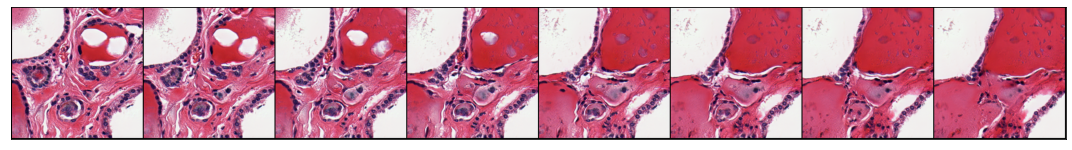

In [49]:
# Doing the projection
pl.figure(1, figsize=(15, 15))
plt = pl.subplot(111)
torch_imshow(Xinter_grid)
plt.set_xticks([])
plt.set_yticks([])
pl.tight_layout()
# pl.savefig(f'{figdir}/randomsamples.png', dpi=300)